# XUV Polarimetry

This example extends the previous one on [Dynamical Magnetic X-ray Scattering](./dynamical_magnetic_xray.ipynb) by showcasing the ability to simulate with variable incoming and outcoing polarization in the XUV and soft-X-ray spectral range. 

:::{versionadded} 2.4.0
Enable variable/elliptical polarization in {py:class}`XrayDynMag <udkm1Dsim.simulations.xrays.XrayDynMag>`
:::

With that it is possible to extend the simulations beyond common geometries of XMCD and transversal [MOKE](https://en.wikipedia.org/wiki/Magneto-optic_Kerr_effect) (__T-MOKE__) to also probe in longitudinal and polar MOKE geometry, __L-MOKE__ and __P-MOKE__, respectively.

Since polarizing optics are hardly available/feasible in the XUV and soft-X-ray spectral range, L- and P-MOKE rely on the sample reflection itself at the Brewster angle as polarization analyzer.
Or in other words, the exact Brewster angle relies on the magnetization and polarization-dependent refractive index.

:::{seealso}
Johanna Richter, et al., _Spectroscopic probe of ultrafast magnetization dynamics in the extreme ultraviolet spectral range_, [Phys. Rev. B 111, 214423 (2025)](https://doi.org/10.1103/kjg2-t36b) 
:::

An overview of the different geometries are given in the following sketch form [Richter, et al.](https://doi.org/10.1103/kjg2-t36b):

![L-, T-, and P-MOKE geometries](XUV_polarimetry.png "L-, T-, and P-MOKE geometries")

Note, that for L- and P-MOKE the linear polarization must be slightly tilted out of the scattering plane.

:::{attention}
In the current example, the polarization angle is referred to as $\alpha$ and __NOT__ $\phi$ as in the sketch from the paper in order to not confuse it with the polar coordinate of the magnetization as otherwise used in the __udkm1Dsim__ toolbox, see [User Guide](../user_guide.rst) for details.
There is further 90° offset between both polarization angles.
:::

The following table summarizes the experimental configurations:

|                            | (a) L-MOKE      |  (b) T-MOKE    | (c) P-MOKE |
| -----------:               | :--------:      |  :--------:    | :--------: |
| __magnetization__ $\gamma$ | 90°             | 0°             |     -      |
| __magnetization__ $\phi$   | 90°             | 90°            |     0°     |
| __polarization__ $\alpha$  | $\neq$ 0°       | $=$ 0°         | $\neq$ 0°  |

## Setup

Do all necessary imports and settings.

In [1]:
import udkm1Dsim as ud
u = ud.u  # import the pint unit registry from udkm1Dsim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units

## Structure

Refer to the [structure-example](structure.ipynb) for more details.

In the XUV spectral range, the atomic form factors from the [Henke tables](http://www.doi.org/10.1006/adnd.1993.1013) are more suitable and can be selected by the keyword `atomic_form_factor_source` in the `Atom` constructor.

In [2]:
Ta = ud.Atom('Ta', atomic_form_factor_source='henke')
Ru = ud.Atom('Ru', atomic_form_factor_source='henke')

Si = ud.Atom('Si', atomic_form_factor_source='henke')
O = ud.Atom('O',  atomic_form_factor_source='henke')

SiO2  = ud.AtomMixed('SiO2')
SiO2.add_atom(Si, 0.33)
SiO2.add_atom(O, 0.67)

For the magnetic Fe atom experimental data for the charge and magnetic form factors is used.

:::{seealso}
Felix Willems, et al. _Magneto-optical functions at the 3p resonances of Fe, Co, and Ni: Ab initio description and experiment_, [Phys. Rev. Lett. 122, 217202 (2019).](https://doi.org/10.1103/PhysRevLett.122.217202)
:::

In [3]:
Fe = ud.Atom('Fe', mag_amplitude=1, mag_phi=90*u.deg, mag_gamma=180*u.deg,
             atomic_form_factor_path='./Fe_XUV.cf',
             magnetic_form_factor_path='./Fe_XUV.mf')

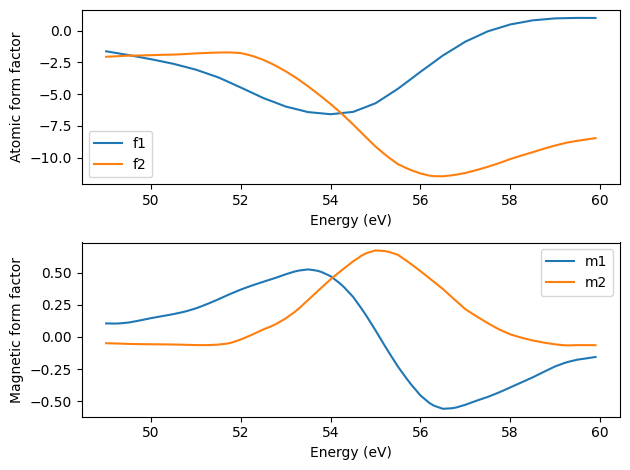

In [4]:
energies = np.r_[49:60:0.1]*u.eV

plt.figure()

plt.subplot(2,1,1)

plt.plot(energies, np.real(Fe.get_atomic_form_factor(energies)), label='f1')
plt.plot(energies, np.imag(Fe.get_atomic_form_factor(energies)), label='f2')

plt.legend()
plt.xlabel('Energy (eV)')
plt.ylabel('Atomic form factor')

plt.subplot(2,1,2)
plt.plot(energies, np.real(Fe.get_magnetic_form_factor(energies)), label='m1')
plt.plot(energies, np.imag(Fe.get_magnetic_form_factor(energies)), label='m2')

plt.legend()
plt.xlabel('Energy (eV)')
plt.ylabel('Magnetic form factor')

plt.tight_layout()
plt.show()

In [5]:
layer_Ta = ud.AmorphousLayer('Ta', 'Ta amorphous', 3*u.nm, 16650*u.kg/u.m**3, atom=Ta)
layer_Ru = ud.AmorphousLayer('Ru', 'Ru amorphous', 2*u.nm, 12370*u.kg/u.m**3, atom=Ru)
layer_SiO2 = ud.AmorphousLayer('SiO2', 'SiO2 amorphous',  100*u.nm, 2650*u.kg/u.m**3, atom=SiO2)
layer_Fe = ud.AmorphousLayer('Fe', 'Fe amorphous', 8*u.nm, 7874*u.kg/u.m**3, atom=Fe)

In [6]:
S = ud.Structure('Fe MOKE')

S.add_sub_structure(layer_Ru,1)
S.add_sub_structure(layer_Fe, 1)
S.add_sub_structure(layer_Ta, 1)
S.add_sub_structure(layer_SiO2, 1)

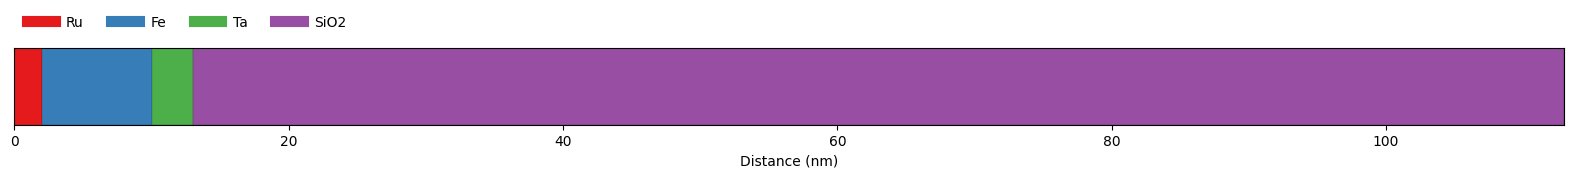

In [7]:
S.visualize()

## Initialize dynamical magnetic X-ray simulations

Please refer to the [Dynamical Magnetic X-ray Scattering](./dynamical_magnetic_xray.ipynb) example for more details.

In [8]:
dyn_mag = ud.XrayDynMag(S, True)
dyn_mag.disp_messages = True
dyn_mag.save_data = False

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized


In [9]:
dyn_mag.energy = 54*u.eV
dyn_mag.theta = np.r_[45]*u.deg

## Polarization settings

In all following simulations the analyzer polarization is kept as *unpolarized*, which is equivalent to

    dyn_mag.set_outgoing_polarization(0)

To enable variable incoming polarization, in the {py:meth}`set_incoming_polarization <udkm1Dsim.simulations.xrays.XrayDynMag.set_incoming_polarization>` method the `pol_in_state` must be set to `5`.

:::{versionadded} 2.4.0
Enable variable/elliptical polarization in {py:class}`XrayDynMag <udkm1Dsim.simulations.xrays.XrayDynMag>`
:::

In this case a single or list of tuple of the azimuth angle $\alpha$ and the ellipticity $e$ of the polarization can be input.

:::{note}
  $$-180° \leq \alpha \leq +180°$$
  $$-1 \leq e \leq +1$$
:::

In [10]:
alphas = np.r_[0:180:0.1]
dyn_mag.set_incoming_polarization(5, [(x*u.deg, 0) for x in alphas])

incoming polarizations set to: elliptical


## T-MOKE

The current experimental configuration already corresponds to the well-known T-MOKE geometry.

Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.026182 s


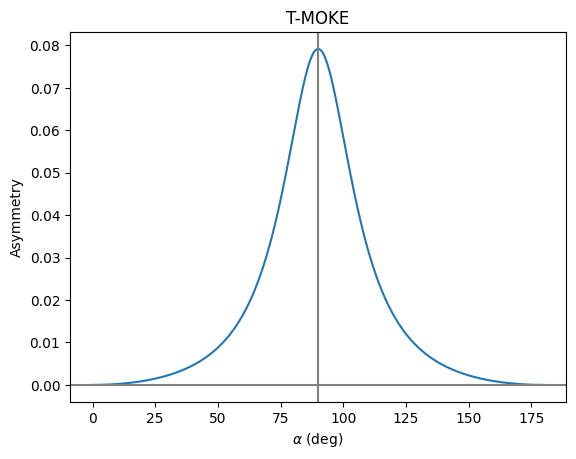

In [11]:
Fe.mag_gamma = 180*u.deg  # s-pol
Fe.mag_phi = 90*u.deg  # in-plane

dyn_mag.theta = np.r_[45]*u.deg

R, R_phi, _, _ = dyn_mag.homogeneous_reflectivity()
asym_tmoke = ((R-R_phi)/(R+R_phi)).flatten()

plt.figure()
plt.plot(alphas, asym_tmoke)
plt.axvline(90, color='gray')
plt.axhline(0, color='gray')
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel('Asymmetry')
plt.title('T-MOKE')
plt.show()

## L-MOKE

Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.026241 s


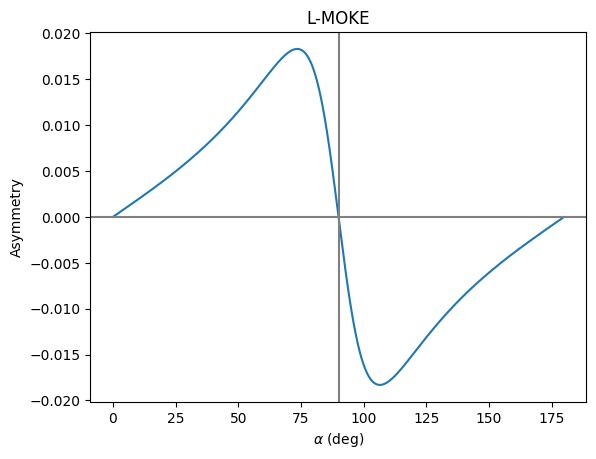

In [12]:
Fe.mag_gamma = 90*u.deg  # p-pol
Fe.mag_phi = 90*u.deg  # in-plane

dyn_mag.theta = np.r_[45]*u.deg

R, R_phi, _, _ = dyn_mag.homogeneous_reflectivity()
asym_lmoke = ((R-R_phi)/(R+R_phi)).flatten()

plt.figure()
plt.plot(alphas, asym_lmoke)
plt.axvline(90, color='gray')
plt.axhline(0, color='gray')
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel('Asymmetry')
plt.title('L-MOKE')
plt.show()

## P-MOKE

Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.025962 s


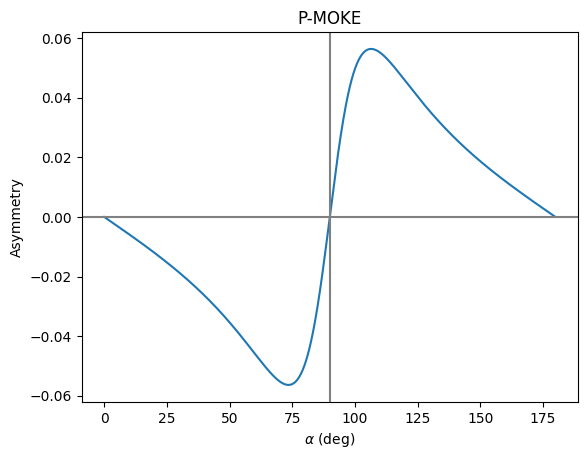

In [13]:
Fe.mag_gamma = 0*u.deg  # any
Fe.mag_phi = 0*u.deg  # out-of-plane

dyn_mag.theta = np.r_[45]*u.deg

R, R_phi, _, _ = dyn_mag.homogeneous_reflectivity()
asym_pmoke = ((R-R_phi)/(R+R_phi)).flatten()

plt.figure()
plt.plot(alphas, asym_pmoke)
plt.axvline(90, color='gray')
plt.axhline(0, color='gray')
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel('Asymmetry')
plt.title('P-MOKE')
plt.show()

Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.175930 s


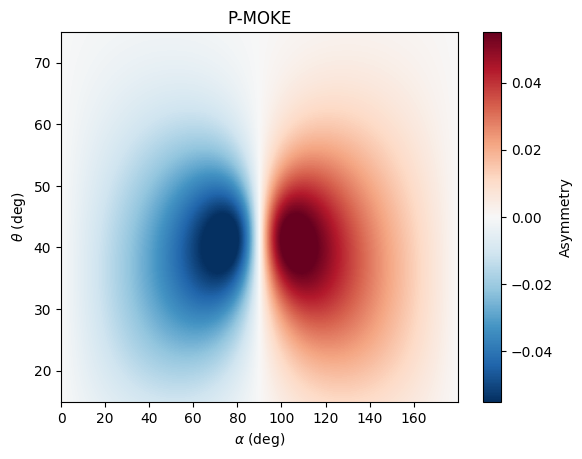

In [14]:
dyn_mag.theta = np.r_[15:75:0.1]*u.deg
R, R_phi, _, _ = dyn_mag.homogeneous_reflectivity()
asym_pmoke_map = ((R-R_phi)/((R+R_phi)))

plt.figure()
plt.pcolormesh(alphas, dyn_mag.theta[0, :], asym_pmoke_map[0, :, :],
               shading='auto', vmin=-.055, vmax=.055, cmap='RdBu_r')
plt.ylabel(r'$\theta$ (deg)')
plt.xlabel(r'$\alpha$ (deg)')
plt.colorbar(label="Asymmetry")
plt.title('P-MOKE')
plt.show()



## Comparison

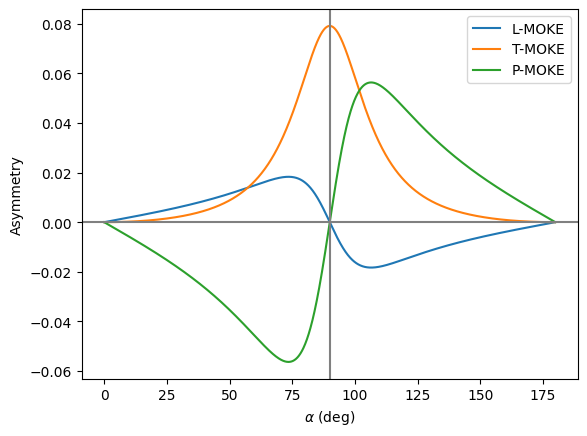

In [15]:
plt.figure()
plt.plot(alphas, asym_lmoke, label='L-MOKE')
plt.plot(alphas, asym_tmoke, label='T-MOKE')
plt.plot(alphas, asym_pmoke, label='P-MOKE')
plt.legend()
plt.axvline(90, color='gray')
plt.axhline(0, color='gray')
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel('Asymmetry')
plt.show()